**SCRAPER DATA**

In [ ]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

**DATA NEGARA INDONESIA**

In [ ]:
result_id, continuation_token = reviews(
    'com.mobile.legends',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=3000
)

In [ ]:
result_ph, continuation_token = reviews(
    'com.mobile.legends',
    lang='en',
    country='ph',
    sort=Sort.NEWEST,
    count=3000
)

In [ ]:
df_id = pd.DataFrame(result_id)
df_id['negara'] = 'Indonesia'

In [ ]:
df_ph = pd.DataFrame(result_ph)
df_ph['negara'] = 'Filipina'

In [ ]:
df = pd.concat([df_id, df_ph], ignore_index=True)

In [ ]:
df = df.rename(columns={
    'content':'review',
    'score':'rating'
})
df = df[['negara','review','rating']]
df.head()

,negara,review,rating
0,Indonesia,"Ni ga ada update update dah dari dulu, suka be...",1
1,Indonesia,game tidak adil tolol dongo,1
2,Indonesia,sistem nya kurang,3
3,Indonesia,mobile legends bagus sekali aku suka mobile le...,5
4,Indonesia,"apalah ni ton, sinyal ngelek mulu",5


In [ ]:
df.iloc[2995:3005]

,negara,review,rating
2995,Indonesia,"tlong dong APUS darksistem monton,kena trol Mu...",1
2996,Indonesia,di kasihnya drak sistem mulu,3
2997,Indonesia,"Makin update bukannya bagus,malahan makin dongo",1
2998,Indonesia,makin hari makin sulit terus capek kena seson ...,1
2999,Indonesia,"apaan sii game gajelas, ga scrip, ga cheat, tb...",1
3000,Filipina,"benerin server lu, ngelag banget eek",3
3001,Filipina,Stupid matchmaking,1
3002,Filipina,game doch kon mi juii mray ah moonton Dak team...,1
3003,Filipina,binanade ni moonton acc konpede patanggal 166day,1
3004,Filipina,love it,5


In [ ]:
df.to_csv("review_mobile_legends.csv", index=False)

**CLEANING DATA**

In [ ]:
import pandas as pd
df=pd.read_csv("review_mobile_legends.csv")

In [ ]:
df.isnull().sum()

,0
negara,0
review,0
rating,0


In [ ]:
df = df.dropna(subset=['review'])

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)  # hapus link

    text = re.sub(r'\d+', '', text)  # hapus angka

    text = re.sub(r'[^\w\s]', '', text)  # hapus tanda baca

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df[['review','clean_review']].head()

,review,clean_review
0,sangat puas,sangat puas
1,"game kikir, gj strees ngasih tim epic hdh",game kikir gj strees ngasih tim epic hdh
2,Game sudah bagus tapi kurangnya kalau mau gant...,game sudah bagus tapi kurangnya kalau mau gant...
3,bagus game nya tp kadang servernya down ga bis...,bagus game nya tp kadang servernya down ga bis...
4,banyak drak sistem,banyak drak sistem


In [ ]:
def label_sentimen(rating):

    if rating <= 2:
        return "negatif"

    elif rating == 3:
        return "netral"

    else:
        return "positif"

df['sentimen_rating'] = df['rating'].apply(label_sentimen)

In [ ]:
df.head()

,negara,review,rating,clean_review,sentimen_rating
0,Indonesia,sangat puas,5,sangat puas,positif
1,Indonesia,"game kikir, gj strees ngasih tim epic hdh",1,game kikir gj strees ngasih tim epic hdh,negatif
2,Indonesia,Game sudah bagus tapi kurangnya kalau mau gant...,5,game sudah bagus tapi kurangnya kalau mau gant...,positif
3,Indonesia,bagus game nya tp kadang servernya down ga bis...,4,bagus game nya tp kadang servernya down ga bis...,positif
4,Indonesia,banyak drak sistem,1,banyak drak sistem,negatif


In [ ]:
df.to_csv("clean review_mobile_legends.csv", index=False)

In [ ]:
pd.crosstab(df['negara'], df['sentimen_rating'])

sentimen_rating,negatif,netral,positif
negara,,,
Filipina,1676,81,1243
Indonesia,1830,115,1055


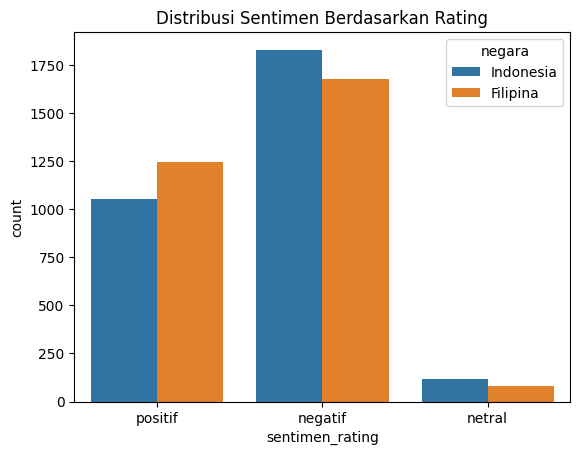

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentimen_rating', hue='negara')

plt.title("Distribusi Sentimen Berdasarkan Rating")
plt.show()

In [ ]:
df['negara'].value_counts()

,count
negara,
Indonesia,3000
Filipina,3000


**DATA TRANSLATE**

In [ ]:
pip install deep-translator tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

In [ ]:
tqdm.pandas()

In [ ]:
translator = GoogleTranslator(source='auto', target='id')

def translate_text(text):

    try:
        return translator.translate(text)

    except:
        return text

In [ ]:
df['review_translate'] = df['review'].progress_apply(translate_text)

100%|██████████| 6000/6000 [51:39<00:00,  1.94it/s]


In [ ]:
#df.to_csv("mlbb_review_translated.csv", index=False)

**ROBERTA**

In [ ]:
df_1=pd.read_csv("mlbb_review_translated.csv")

In [ ]:
df_1.loc[4555:5555, ['negara','review','review_translate']]

,negara,review,review_translate
4555,Filipina,matchmaking nya ga seimbang,matchmaking nya ga seimbang
4556,Filipina,this game it's making so many unfair and dog s...,game ini membuat banyak sistem tidak adil dan ...
4557,Filipina,mlbb mo bulok,kamu busuk
4558,Filipina,asal setiap kali mati lebih 5 coklat eh sikit2...,asli tiap mati lebih dari 5 coklat eh coklat k...
4559,Filipina,this game is so cool you must try it now 🇵🇭,game ini keren banget kamu wajib coba sekarang
...,...,...,...
5551,Filipina,👎 because when you on winstreak the next game ...,👎 karena ketika kamu sedang winstreak di game ...
5552,Filipina,"нет баланса, не было и не будет","tidak ada keseimbangan, tidak pernah ada dan t..."
5553,Filipina,Best game,Permainan terbaik
5554,Filipina,It's time for us to leave mlbb and join the re...,Sudah waktunya kita meninggalkan mlbb dan berg...


In [ ]:
pip install transformers torch

In [ ]:
from transformers import pipeline

In [ ]:
from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
from tqdm import tqdm

# Ambil teks review
texts = df_1['review_translate'].fillna("").astype(str).tolist()

batch_size = 32
predictions = []

# Prediksi IndoBERT per batch
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]

    results = sentiment(
        batch,
        truncation=True,   # otomatis potong >512 token
        padding=True,
        max_length=512     # Menambahkan max_length untuk memastikan input tidak melebihi batas model
    )

    for r in results:
        predictions.append(r['label'])

# Simpan hasil ke dataframe
df_1['prediksi_indobert'] = predictions

100%|██████████| 188/188 [16:13<00:00,  5.18s/it]


In [ ]:
df_1[['review_translate','prediksi_indobert']].head(5)

,review_translate,prediksi_indobert
0,sangat puas,positive
1,"game kikir, gj strees ngasih tim epic hdh",negative
2,Game sudah bagus tapi kurangnya kalau mau gant...,negative
3,bagus game nya tp kadang servernya down ga bis...,negative
4,banyak drak sistem,negative


In [ ]:
df_1['prediksi_indobert'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [ ]:
pd.crosstab(df_1['negara'], df_1['prediksi_indobert'], normalize='index') * 100

prediksi_indobert,negative,neutral,positive
negara,,,
Filipina,58.966667,8.366667,32.666667
Indonesia,67.400000,7.600000,25.000000


In [ ]:
def simplify_sentiment(label):
    if label == "negative":
        return "negatif"
    elif label == "neutral":
        return "netral"
    elif label == "positive":
        return "positif"
    else:
        return None # Handle unexpected labels if any

df_1["sentimen_final"] = df_1["prediksi_indobert"].apply(simplify_sentiment)

In [ ]:
pd.crosstab(df_1['negara'], df_1['sentimen_final'], normalize='index') * 100

sentimen_final,negatif,netral,positif
negara,,,
Filipina,58.966667,8.366667,32.666667
Indonesia,67.400000,7.600000,25.000000


In [ ]:
pd.crosstab(
    [df_1['negara'], df_1['sentimen_rating']],
    df_1['sentimen_final'],
    normalize='index'
) * 100

sentimen_final               negatif    netral    positif
negara    sentimen_rating                                
Filipina  negatif          85.799523  7.577566   6.622912
          netral           76.543210  6.172840  17.283951
          positif          21.641191  9.573612  68.785197
Indonesia negatif          86.284153  6.885246   6.830601
          netral           76.521739  7.826087  15.652174
          positif          33.649289  8.815166  57.535545

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = df['sentimen_rating']
y_pred = df_1['sentimen_final']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7488333333333334
Precision: 0.789654277174902
Recall   : 0.7488333333333334
F1 Score : 0.7625759720733528


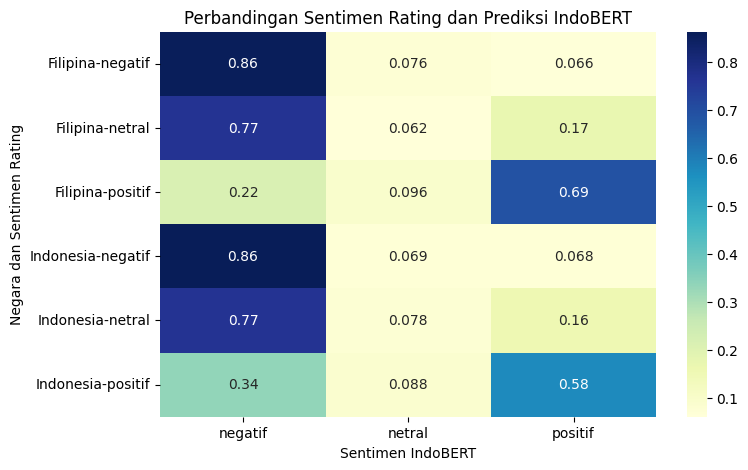

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tab = pd.crosstab(
    [df_1['negara'], df_1['sentimen_rating']],
    df_1['sentimen_final'],
    normalize='index'
)

plt.figure(figsize=(8,5))

sns.heatmap(tab, annot=True, cmap="YlGnBu")

plt.title("Perbandingan Sentimen Rating dan Prediksi IndoBERT")
plt.xlabel("Sentimen IndoBERT")
plt.ylabel("Negara dan Sentimen Rating")

plt.show()

**PREPROCESSING WORDCLOUD**

In [ ]:
!pip install Sastrawi
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.0 MB/s eta 0:00:00


In [ ]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())
stopwords.update(["game","mobile","legend","ml","yg","aja","di","kontol","tapi","maka","ke","dari","ini","itu","saya","dan","nya","player","montoon","monton","moonton","gua","ga","gak","gw","aku"])

In [ ]:
def clean_text(text):

    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # hapus tanda baca

    words = text.split()

    words = [word for word in words if word not in stopwords]

    return " ".join(words)

In [ ]:
df["clean_review"] = df["review"].astype(str).apply(clean_text)

In [ ]:
positif = df[df_1["sentimen_final"]=="positif"]["clean_review"]
negatif = df[df_1["sentimen_final"]=="negatif"]["clean_review"]
netral  = df[df_1["sentimen_final"]=="netral"]["clean_review"]

In [ ]:
positif_text = " ".join(positif)
negatif_text = " ".join(negatif)
netral_text  = " ".join(netral)

**WORDCLOUD POSITIF**

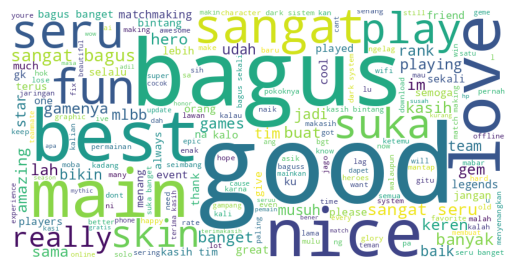

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(positif_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

**WORDCLOUD NEGATIF**

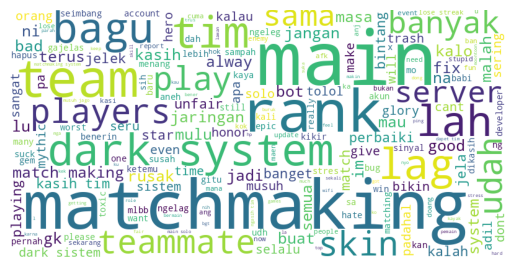

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(negatif_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

**WORDCLOUD NETRAL**

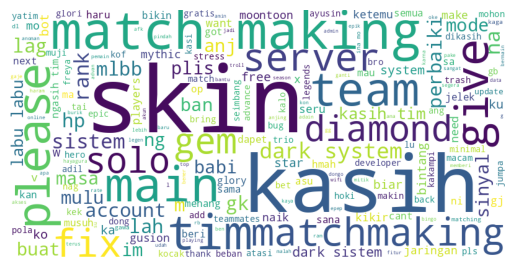

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(netral_text)

plt.imshow(wc)
plt.axis("off")
plt.show()